#  Binary Classification - Cat/Dog **
  **Dr. Christelle Scharff | Dr. Kaleema**
  


In this notebook, we will use a CNN model for classifying images of dogs and cats.

**Convolutional Neural Networks (CNNs) Overview**

CNNs are a class of deep learning models primarily used for image recognition and computer vision tasks.

CNNs automatically learn features from images by using a combination of convolutional layers, pooling layers, and fully connected layers.

**Convolutional Layers**

The core building blocks of CNNs are CNN layers, where a filter (kernel) is applied to an image to detect local patterns such as edges, corners, and textures.

In this case, each convolutional layer applies a series of filters to detect different features of the image (e.g., edges, textures).

The first convolutional layer typically learns low-level features, while deeper layers learn higher-level, more abstract features.

**Max Pooling Layers**

Max pooling reduces the dimensionality of the feature maps while retaining important information. It selects the maximum value from a set of pixels in the feature map.

Pooling helps reduce computation and prevents overfitting.

**Flatten Layer**

After several convolutional and pooling layers, the feature maps need to be flattened (converted into a 1D vector) to feed into the fully connected layers.

The Flatten() layer reshapes the 3D data into a 1D array.

**Fully Connected Layers (Dense Layers)**

These are traditional neural network layers that connect all the neurons from the previous layer to each neuron in the current layer.

**Softmax Activation**

In the final layer, there is typically an activation function. Softmax is used for multi-class classification to predict the class. It outputs a probablily distribution across multiple classes where the probabilities sum is 1.

**Sigmoid Activation**

For binary classification, the sigmoid function is used and outputs a probability between 0 and 1.

**Dropout (Optional but Recommended)**

Dropout is a technique used during training to randomly drop some neurons from the network, preventing overfitting by forcing the network to generalize better.

##### **Importing Cat_Dog_Dataset from Kaggle**

Ensure you have kagglehub installed. If not, install it using: pip install kagglehub

In [1]:
import kagglehub
import shutil
import os
# Download latest version
path = kagglehub.dataset_download("tongpython/cat-and-dog")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cat-and-dog' dataset.
Path to dataset files: /kaggle/input/cat-and-dog


In [2]:
# Define local save path
local_path = "./CatDog_dataset/"

# Ensure the local directory exists
os.makedirs(local_path, exist_ok=True)

# Copy the dataset to the local directory
for item in os.listdir(path):
    s = os.path.join(path, item)
    d = os.path.join(local_path, item)
    if os.path.isdir(s):
        shutil.copytree(s, d)
    else:
        shutil.copy2(s, d)

print(f"Dataset saved at: {local_path}")

print(f"Dataset saved at: {local_path}")

Dataset saved at: ./CatDog_dataset/
Dataset saved at: ./CatDog_dataset/


##### **Import Required Libraries for CNN**

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

##### **Define Paths and Load Dataset**

In [4]:
# Correcting paths
train_dir = "/content/CatDog_dataset/training_set/training_set"
test_dir = "/content/CatDog_dataset/test_set/test_set"

# Define ImageDataGenerator for augmentation and rescaling
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Load training dataset
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

# Load testing dataset
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)


Found 8005 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.


##### **Create a Simple CNN Model**

In [5]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Binary classification (Cat vs Dog)
])

# Compile the model
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


##### **Train the Model**

In [6]:
history = model.fit(
    train_generator,
    epochs=3,
    validation_data=test_generator
)


Epoch 1/3
251/251 ━━━━━━━━━━━━━━━━━━━━ 67s 244ms/step - accuracy: 0.5449 - loss: 0.7064 - val_accuracy: 0.6139 - val_loss: 0.6578
Epoch 2/3
251/251 ━━━━━━━━━━━━━━━━━━━━ 56s 225ms/step - accuracy: 0.6250 - loss: 0.6410 - val_accuracy: 0.6911 - val_loss: 0.5917
Epoch 3/3
251/251 ━━━━━━━━━━━━━━━━━━━━ 57s 228ms/step - accuracy: 0.6636 - loss: 0.6154 - val_accuracy: 0.7084 - val_loss: 0.5662


##### **Evaluate & Test the Model**

In [7]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.2f}")


64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.7084 - loss: 0.5662
Test Accuracy: 0.71


##### **Predict on a New Image**

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(150, 150))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0  # Normalize

    prediction = model.predict(img_array)
    label = "Dog" if prediction[0][0] > 0.5 else "Cat"

    # Display the image
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {label}", fontsize=14, fontweight='bold')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 756ms/step


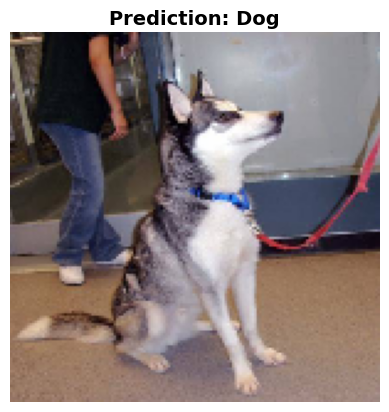

In [9]:
# Example usage
img_path = "/content/CatDog_dataset/test_set/test_set/dogs/dog.4001.jpg"
predict_image(img_path)